# AIF360 Fairness Audit Figure Notebook

This notebook reads the calculation outputs from `results/aif360/` and creates one main figure plus one supplementary figure at 170 mm width.

Run `01_aif360_fairness_calculation.ipynb` before this notebook.


In [1]:
# Import required libraries.
from pathlib import Path
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore")


In [2]:
# Define project paths and publication figure settings.
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name.lower() == "code":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

RESULTS_DIR = PROJECT_ROOT / "results" / "aif360"
FIGURES_DIR = PROJECT_ROOT / "figures" / "aif360"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MM_TO_INCH = 1 / 25.4
FIGURE_WIDTH_MM = 170
FIGURE_WIDTH_IN = FIGURE_WIDTH_MM * MM_TO_INCH
DPI = 600

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "figure.dpi": 120,
    "savefig.dpi": DPI,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Figures directory: {FIGURES_DIR}")


Project root: c:\Users\junse\Documents\research\IUBDC 2026\AIF360
Results directory: c:\Users\junse\Documents\research\IUBDC 2026\AIF360\results\aif360
Figures directory: c:\Users\junse\Documents\research\IUBDC 2026\AIF360\figures\aif360


In [3]:
# Load calculation outputs created by the first notebook.
def read_required_csv(filename):
    path = RESULTS_DIR / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing required file: {path}. Run 01_aif360_fairness_calculation.ipynb first."
        )
    return pd.read_csv(path)

subgroup_composition = read_required_csv("cohort_subgroup_composition.csv")
subgroup_performance = read_required_csv("subgroup_performance_primary_model.csv")
fairness_metrics = read_required_csv("aif360_fairness_metrics_primary_model.csv")
confusion_rates = read_required_csv("aif360_confusion_rates_primary_model.csv")
observed_vs_predicted = read_required_csv("aif360_observed_vs_predicted_primary_model.csv")
threshold_sensitivity = read_required_csv("aif360_threshold_sensitivity_primary_model.csv")
model_performance = read_required_csv("model_performance_external_test.csv")

primary_model_path = RESULTS_DIR / "primary_model_name.txt"
if primary_model_path.exists():
    PRIMARY_MODEL = primary_model_path.read_text().strip()
else:
    PRIMARY_MODEL = subgroup_performance["model"].iloc[0]

print(f"Primary model for the fairness figure: {PRIMARY_MODEL}")


Primary model for the fairness figure: XGBoost


In [4]:
# Define label formatting and plotting helper functions.
attribute_order = {"Age": 0, "Gender": 1, "ICUType": 2}
group_order = {
    "<=65": 0,
    ">65": 1,
    "Female": 2,
    "Male": 3,
    "Cardiac Surgery Recovery Unit": 4,
    "Coronary Care Unit": 5,
    "Medical ICU": 6,
    "Surgical ICU": 7,
}

def display_group(group):
    mapping = {
        "<=65": "Age <=65",
        ">65": "Age >65",
        "Female": "Female",
        "Male": "Male",
        "Cardiac Surgery Recovery Unit": "Cardiac surgery\nrecovery unit",
        "Coronary Care Unit": "Coronary care\nunit",
        "Medical ICU": "Medical ICU",
        "Surgical ICU": "Surgical ICU",
        "Other": "Other",
    }
    return mapping.get(str(group), textwrap.fill(str(group), width=18))

def display_comparison(attribute, comparison):
    text = str(comparison)
    text = text.replace("Cardiac Surgery Recovery Unit", "CSRU")
    text = text.replace("Coronary Care Unit", "CCU")
    if attribute == "Age":
        return "Age >65 vs <=65"
    if attribute == "Gender":
        return "Female vs male"
    return text.replace("Other vs ", "Other vs ")

def panel_title(ax, label, title, x=0.0, y=1.04):
    ax.text(
        x,
        y,
        rf"$\bf{{{label})}}$ {title}",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=8,
    )

def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def add_cell_text(ax, data, fmt="{:.2f}", threshold=0.55):
    finite_values = np.asarray(data, dtype=float)
    max_abs = np.nanmax(np.abs(finite_values)) if np.isfinite(finite_values).any() else 1
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data[i, j]
            if pd.isna(value):
                label = "NA"
                color = "black"
            else:
                label = fmt.format(value)
                color = "white" if abs(value) > threshold * max_abs else "black"
            ax.text(j, i, label, ha="center", va="center", fontsize=6, color=color)

def make_diverging_heatmap(ax, data, row_labels, col_labels, clim=1.0, cbar_label=None):
    values = np.asarray(data, dtype=float)
    clipped_values = np.clip(values, -clim, clim)
    im = ax.imshow(
        clipped_values,
        aspect="auto",
        cmap="BrBG",
        norm=TwoSlopeNorm(vmin=-clim, vcenter=0, vmax=clim),
    )
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels)
    ax.tick_params(length=0)
    add_cell_text(ax, values)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks(np.arange(values.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(values.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)
    cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.ax.tick_params(labelsize=6, length=2)
    if cbar_label:
        cbar.set_label(cbar_label, fontsize=7)
    return im

def make_sequential_heatmap(ax, data, row_labels, col_labels, cbar_label=None):
    values = np.asarray(data, dtype=float)
    im = ax.imshow(
        values,
        aspect="auto",
        cmap="YlGnBu",
        norm=Normalize(vmin=0, vmax=max(1, np.nanmax(values))),
    )
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_xticklabels(col_labels)
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels)
    ax.tick_params(length=0)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            value = values[i, j]
            color = "white" if value > 0.55 else "black"
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=6, color=color)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks(np.arange(values.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(values.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)
    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.tick_params(labelsize=6, length=2)
    if cbar_label:
        cbar.set_label(cbar_label, fontsize=7)
    return im


In [5]:
# Prepare clean plotting tables.
composition_plot = subgroup_composition.copy()
composition_plot["order"] = composition_plot["group"].map(group_order).fillna(99)
composition_plot = composition_plot.sort_values("order").reset_index(drop=True)
composition_plot["display"] = composition_plot["group"].map(display_group)

performance_plot = subgroup_performance.copy()
performance_plot["order"] = performance_plot["group"].map(group_order).fillna(99)
performance_plot = performance_plot.sort_values("order").reset_index(drop=True)
performance_plot["display"] = performance_plot["group"].map(display_group)

fairness_plot = fairness_metrics.copy()
fairness_plot["attribute_order"] = fairness_plot["attribute"].map(attribute_order).fillna(99)
fairness_plot = fairness_plot.sort_values(["attribute_order", "comparison"]).reset_index(drop=True)
fairness_plot["display"] = [
    display_comparison(attribute, comparison)
    for attribute, comparison in zip(fairness_plot["attribute"], fairness_plot["comparison"])
]
fairness_plot["log2_disparate_impact"] = np.log2(
    fairness_plot["disparate_impact_ratio"].replace(0, np.nan)
)

fairness_cols = [
    "statistical_parity_difference",
    "log2_disparate_impact",
    "equal_opportunity_difference",
    "average_odds_difference",
]
fairness_col_labels = ["SPD", "log2(DI)", "EOD", "AOD"]


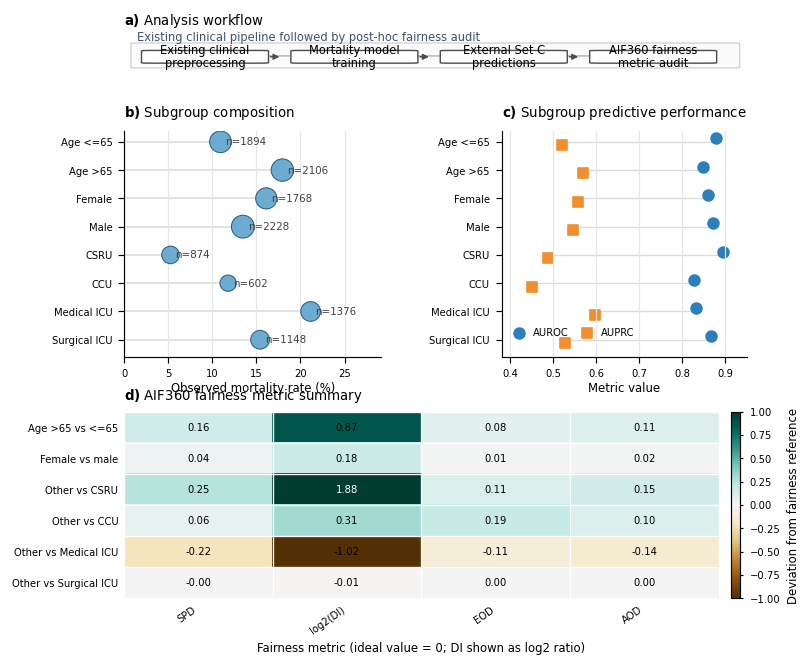

Saved: c:\Users\junse\Documents\research\IUBDC 2026\AIF360\figures\aif360\Figure5_AIF360_fairness_audit_170mm.png
Saved: c:\Users\junse\Documents\research\IUBDC 2026\AIF360\figures\aif360\Figure5_AIF360_fairness_audit_170mm.pdf
Saved: c:\Users\junse\Documents\research\IUBDC 2026\AIF360\figures\aif360\Figure5_AIF360_fairness_audit_170mm.svg


In [6]:
# Create the main 170 mm figure.
fig = plt.figure(figsize=(FIGURE_WIDTH_IN, 156 * MM_TO_INCH))
gs = GridSpec(
    3,
    2,
    figure=fig,
    height_ratios=[0.34, 1.72, 1.42],
    width_ratios=[1.05, 1.00],
    hspace=0.36,
    wspace=0.48,
)
ax_a = fig.add_subplot(gs[0, :])
ax_b = fig.add_subplot(gs[1, 0])
ax_c = fig.add_subplot(gs[1, 1])
ax_d = fig.add_subplot(gs[2, :])

# Define compact subgroup labels for the upper data panels.
compact_group_labels = {
    "Age <=65": "Age <=65",
    "Age >65": "Age >65",
    "Female": "Female",
    "Male": "Male",
    "Cardiac surgery\nrecovery unit": "CSRU",
    "Coronary care\nunit": "CCU",
    "Medical ICU": "Medical ICU",
    "Surgical ICU": "Surgical ICU",
}
composition_labels = [compact_group_labels.get(label, label) for label in composition_plot["display"]]
performance_labels = [compact_group_labels.get(label, label) for label in performance_plot["display"]]

# Draw panel a: workflow.
ax_a.set_axis_off()
panel_title(ax_a, "a", "Analysis workflow", y=1.03)
ax_a.text(
    0.02,
    0.86,
    "Existing clinical pipeline followed by post-hoc fairness audit",
    ha="left",
    va="center",
    fontsize=6.9,
    color="#3F536E",
)

# Add a compact publication-style workflow band.
band_x, band_y, band_w, band_h = 0.02, 0.18, 0.96, 0.54
band = patches.FancyBboxPatch(
    (band_x, band_y),
    band_w,
    band_h,
    boxstyle="round,pad=0.009,rounding_size=0.008",
    linewidth=0.7,
    edgecolor="0.80",
    facecolor="0.985",
    zorder=0,
)
ax_a.add_patch(band)

# Add a subtle directional guide behind the boxes.
ax_a.annotate(
    "",
    xy=(0.90, 0.44),
    xytext=(0.08, 0.44),
    arrowprops=dict(arrowstyle="-|>", lw=0.9, color="0.72"),
    zorder=1,
)

box_y = 0.29
box_h = 0.26
box_w = 0.18
box_xs = [0.04, 0.28, 0.52, 0.76]
box_texts = [
    "Existing clinical\npreprocessing",
    "Mortality model\ntraining",
    "External Set C\npredictions",
    "AIF360 fairness\nmetric audit",
]
for x, text in zip(box_xs, box_texts):
    rect = patches.FancyBboxPatch(
        (x, box_y),
        box_w,
        box_h,
        boxstyle="round,pad=0.012,rounding_size=0.010",
        linewidth=0.85,
        edgecolor="0.30",
        facecolor="white",
        zorder=2,
    )
    ax_a.add_patch(rect)
    ax_a.text(
        x + box_w / 2,
        box_y + box_h / 2,
        text,
        ha="center",
        va="center",
        fontsize=6.9,
        linespacing=1.06,
        zorder=3,
    )
for x0 in [box_xs[0] + box_w, box_xs[1] + box_w, box_xs[2] + box_w]:
    ax_a.annotate(
        "",
        xy=(x0 + 0.035, box_y + box_h / 2),
        xytext=(x0 + 0.010, box_y + box_h / 2),
        arrowprops=dict(arrowstyle="-|>", lw=0.9, color="0.30"),
        zorder=3,
    )
ax_a.set_xlim(0, 1)
ax_a.set_ylim(0, 1)

# Draw panel b: subgroup composition.
panel_title(ax_b, "b", "Subgroup composition")
y_positions = np.arange(len(composition_plot))
x_values = composition_plot["mortality_rate"] * 100
marker_sizes = 62 + composition_plot["n"] / composition_plot["n"].max() * 125
ax_b.hlines(y_positions, xmin=0, xmax=x_values, color="0.86", linewidth=0.9, zorder=0)
ax_b.scatter(
    x_values,
    y_positions,
    s=marker_sizes,
    color="#67A9CF",
    alpha=0.96,
    edgecolor="#2B5D80",
    linewidth=0.65,
    zorder=3,
)
for y, x, n in zip(y_positions, x_values, composition_plot["n"]):
    ax_b.text(x + 0.55, y, f"n={int(n)}", va="center", fontsize=6.2, color="0.25")
ax_b.set_yticks(y_positions)
ax_b.set_yticklabels(composition_labels)
ax_b.set_ylim(len(y_positions) - 0.4, -0.4)
ax_b.set_xlabel("Observed mortality rate (%)", labelpad=2)
ax_b.set_xlim(0, max(26, x_values.max() + 8))
ax_b.set_xticks(np.arange(0, 26, 5))
ax_b.grid(axis="x", color="0.90", linewidth=0.7)
clean_axis(ax_b)

# Draw panel c: subgroup predictive performance.
panel_title(ax_c, "c", "Subgroup predictive performance")
y_positions = np.arange(len(performance_plot))
ax_c.scatter(
    performance_plot["auroc"],
    y_positions - 0.12,
    s=42,
    label="AUROC",
    marker="o",
    color="#2C7FB8",
)
ax_c.scatter(
    performance_plot["auprc"],
    y_positions + 0.12,
    s=42,
    label="AUPRC",
    marker="s",
    color="#F28E2B",
)
for i in y_positions:
    ax_c.plot(
        [performance_plot.loc[i, "auprc"], performance_plot.loc[i, "auroc"]],
        [i, i],
        color="0.86",
        lw=0.8,
        zorder=0,
    )
ax_c.set_yticks(y_positions)
ax_c.set_yticklabels(performance_labels)
ax_c.set_ylim(len(y_positions) - 0.4, -0.4)
ax_c.set_xlabel("Metric value", labelpad=2)
ax_c.set_xlim(0.38, 0.95)
ax_c.grid(axis="x", color="0.90", linewidth=0.7)
ax_c.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.00, 0.16),
    ncol=2,
    handletextpad=0.4,
    columnspacing=0.9,
    borderpad=0.2,
)
clean_axis(ax_c)

# Draw panel d: AIF360 fairness metric heatmap.
panel_title(ax_d, "d", "AIF360 fairness metric summary")
heat_values = fairness_plot[fairness_cols].to_numpy(float)
make_diverging_heatmap(
    ax_d,
    heat_values,
    fairness_plot["display"].tolist(),
    fairness_col_labels,
    clim=1.0,
    cbar_label="Deviation from fairness reference",
)
ax_d.set_xlabel("Fairness metric (ideal value = 0; DI shown as log2 ratio)")

# Save the main figure.
main_png_path = FIGURES_DIR / "Figure5_AIF360_fairness_audit_170mm.png"
main_pdf_path = FIGURES_DIR / "Figure5_AIF360_fairness_audit_170mm.pdf"
main_svg_path = FIGURES_DIR / "Figure5_AIF360_fairness_audit_170mm.svg"
fig.savefig(main_png_path, dpi=DPI, bbox_inches="tight", pad_inches=0.02)
fig.savefig(main_pdf_path, bbox_inches="tight", pad_inches=0.02)
fig.savefig(main_svg_path, format="svg", bbox_inches="tight", pad_inches=0.02)
plt.show()

print(f"Saved: {main_png_path}")
print(f"Saved: {main_pdf_path}")
print(f"Saved: {main_svg_path}")





In [7]:
# Prepare supplementary plotting tables.
observed_actual = observed_vs_predicted[observed_vs_predicted["group"] != "Other"].copy()
observed_actual["order"] = observed_actual["group"].map(group_order).fillna(99)
observed_actual = observed_actual.sort_values("order").drop_duplicates(["attribute", "group"]).reset_index(drop=True)
observed_actual["display"] = observed_actual["group"].map(display_group)

confusion_actual = confusion_rates[confusion_rates["group"] != "Other"].copy()
confusion_actual["order"] = confusion_actual["group"].map(group_order).fillna(99)
confusion_actual = confusion_actual.sort_values("order").drop_duplicates(["attribute", "group"]).reset_index(drop=True)
confusion_actual["display"] = confusion_actual["group"].map(display_group)

icu_fairness_plot = fairness_plot[fairness_plot["attribute"] == "ICUType"].copy().reset_index(drop=True)

threshold_plot = threshold_sensitivity.copy()
threshold_plot["log2_disparate_impact"] = np.log2(threshold_plot["disparate_impact_ratio"].replace(0, np.nan))
threshold_plot = threshold_plot[np.isclose((threshold_plot["threshold"] * 10) % 1, 0, atol=1e-8)].copy()

threshold_rows = []
for threshold, part in threshold_plot.groupby("threshold"):
    threshold_rows.append({
        "threshold": threshold,
        "SPD": np.nanmax(np.abs(part["statistical_parity_difference"])),
        "log2(DI)": np.nanmax(np.abs(part["log2_disparate_impact"])),
        "EOD": np.nanmax(np.abs(part["equal_opportunity_difference"])),
        "AOD": np.nanmax(np.abs(part["average_odds_difference"])),
    })
threshold_summary = pd.DataFrame(threshold_rows).sort_values("threshold").reset_index(drop=True)


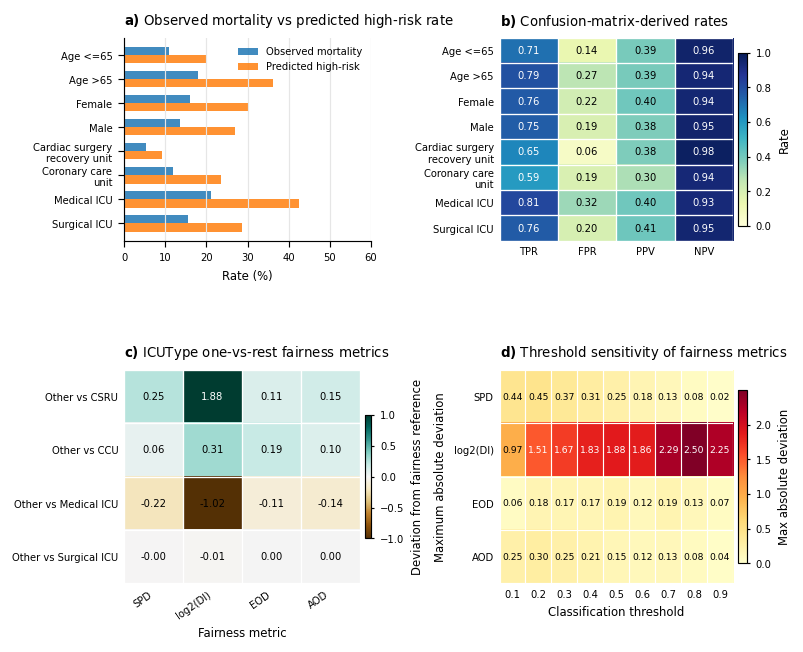

Saved: c:\Users\junse\Documents\research\IUBDC 2026\AIF360\figures\aif360\Supplementary_FigureS_AIF360_subgroup_diagnostics_170mm.png
Saved: c:\Users\junse\Documents\research\IUBDC 2026\AIF360\figures\aif360\Supplementary_FigureS_AIF360_subgroup_diagnostics_170mm.pdf


In [8]:
# Create the supplementary 170 mm figure.
fig = plt.figure(figsize=(FIGURE_WIDTH_IN, 150 * MM_TO_INCH))
gs = GridSpec(
    2,
    2,
    figure=fig,
    height_ratios=[1.0, 1.05],
    width_ratios=[1.0, 1.0],
    hspace=0.62,
    wspace=0.52,
)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

# Draw panel a: observed mortality versus predicted high-risk rate.
panel_title(ax_a, "a", "Observed mortality vs predicted high-risk rate")
y_positions = np.arange(len(observed_actual))
bar_height = 0.34
ax_a.barh(
    y_positions - bar_height / 2,
    observed_actual["observed_mortality_rate"] * 100,
    height=bar_height,
    label="Observed mortality",
    alpha=0.85,
)
ax_a.barh(
    y_positions + bar_height / 2,
    observed_actual["predicted_high_risk_rate"] * 100,
    height=bar_height,
    label="Predicted high-risk",
    alpha=0.85,
)
ax_a.set_yticks(y_positions)
ax_a.set_yticklabels(observed_actual["display"])
ax_a.invert_yaxis()
ax_a.set_xlabel("Rate (%)")
ax_a.set_xlim(0, max(60, observed_actual["predicted_high_risk_rate"].max() * 100 + 10))
ax_a.grid(axis="x", color="0.90", linewidth=0.7)
ax_a.legend(frameon=False, loc="upper right")
clean_axis(ax_a)

# Draw panel b: confusion-matrix-derived rates.
panel_title(ax_b, "b", "Confusion-matrix-derived rates")
rate_cols = ["tpr", "fpr", "ppv", "npv"]
rate_labels = ["TPR", "FPR", "PPV", "NPV"]
make_sequential_heatmap(
    ax_b,
    confusion_actual[rate_cols].to_numpy(float),
    confusion_actual["display"].tolist(),
    rate_labels,
    cbar_label="Rate",
)

# Draw panel c: ICUType one-vs-rest fairness metrics.
panel_title(ax_c, "c", "ICUType one-vs-rest fairness metrics")
make_diverging_heatmap(
    ax_c,
    icu_fairness_plot[fairness_cols].to_numpy(float),
    icu_fairness_plot["display"].tolist(),
    fairness_col_labels,
    clim=1.0,
    cbar_label="Deviation from fairness reference",
)
ax_c.set_xlabel("Fairness metric")

# Draw panel d: threshold sensitivity heatmap.
panel_title(ax_d, "d", "Threshold sensitivity of fairness metrics")
metric_rows = ["SPD", "log2(DI)", "EOD", "AOD"]
threshold_labels = [f"{value:.1f}" for value in threshold_summary["threshold"]]
threshold_values = threshold_summary[metric_rows].T.to_numpy(float)
im = ax_d.imshow(
    threshold_values,
    aspect="auto",
    cmap="YlOrRd",
    norm=Normalize(vmin=0, vmax=np.nanmax(threshold_values)),
)
ax_d.set_xticks(np.arange(len(threshold_labels)))
ax_d.set_xticklabels(threshold_labels)
ax_d.set_yticks(np.arange(len(metric_rows)))
ax_d.set_yticklabels(metric_rows)
ax_d.set_xlabel("Classification threshold")
ax_d.set_ylabel("Maximum absolute deviation")
ax_d.tick_params(length=0)
for i in range(threshold_values.shape[0]):
    for j in range(threshold_values.shape[1]):
        value = threshold_values[i, j]
        color = "white" if value > 0.55 * np.nanmax(threshold_values) else "black"
        ax_d.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=5.5, color=color)
for spine in ax_d.spines.values():
    spine.set_visible(False)
ax_d.set_xticks(np.arange(threshold_values.shape[1] + 1) - 0.5, minor=True)
ax_d.set_yticks(np.arange(threshold_values.shape[0] + 1) - 0.5, minor=True)
ax_d.grid(which="minor", color="white", linewidth=0.7)
ax_d.tick_params(which="minor", bottom=False, left=False)
cbar = plt.colorbar(im, ax=ax_d, fraction=0.035, pad=0.02)
cbar.ax.tick_params(labelsize=6, length=2)
cbar.set_label("Max absolute deviation", fontsize=7)

# Save the supplementary figure.
supp_png_path = FIGURES_DIR / "Supplementary_FigureS_AIF360_subgroup_diagnostics_170mm.png"
supp_pdf_path = FIGURES_DIR / "Supplementary_FigureS_AIF360_subgroup_diagnostics_170mm.pdf"
fig.savefig(supp_png_path, dpi=DPI, bbox_inches="tight", pad_inches=0.02)
fig.savefig(supp_pdf_path, bbox_inches="tight", pad_inches=0.02)
plt.show()

print(f"Saved: {supp_png_path}")
print(f"Saved: {supp_pdf_path}")


In [9]:
# Print Overleaf-ready figure snippets.
main_caption = r'''
\begin{figure}[H]
    \centering
    \includegraphics[width=170mm]{figures/aif360/Figure5_AIF360_fairness_audit_170mm.png}
    \caption{Post-hoc AIF360 subgroup fairness audit of ICU mortality prediction.
    \textbf{a)}, Analysis workflow showing that AIF360 was applied after the existing clinical preprocessing and model prediction pipeline, without applying AIF360 fairness-mitigation preprocessing in the primary analysis.
    \textbf{b)}, Subgroup composition in the external test cohort, with marker size proportional to subgroup sample size and x-axis showing observed mortality prevalence.
    \textbf{c)}, Subgroup predictive performance for the primary mortality model.
    \textbf{d)}, AIF360 fairness metric summary for predicted mortality risk across age, gender, and ICU type comparisons. Disparate impact is displayed as log2(DI), so zero indicates the fairness reference value.}
    \label{fig:aif360_fairness_audit}
\end{figure}
'''.strip()

supp_caption = r'''
\begin{figure}[H]
    \centering
    \includegraphics[width=170mm]{figures/aif360/Supplementary_FigureS_AIF360_subgroup_diagnostics_170mm.png}
    \caption{Detailed subgroup diagnostics supporting the AIF360 fairness audit.
    \textbf{a)}, Observed mortality rate and predicted high-risk rate by subgroup.
    \textbf{b)}, Confusion-matrix-derived subgroup rates.
    \textbf{c)}, ICU type one-vs-rest fairness metric details.
    \textbf{d)}, Threshold sensitivity of fairness metrics, summarized as the maximum absolute deviation across subgroup comparisons at each classification threshold.}
    \label{fig:supp_aif360_diagnostics}
\end{figure}
'''.strip()

print("Main figure LaTeX snippet:")
print(main_caption)
print("\nSupplementary figure LaTeX snippet:")
print(supp_caption)


Main figure LaTeX snippet:
\begin{figure}[H]
    \centering
    \includegraphics[width=170mm]{figures/aif360/Figure5_AIF360_fairness_audit_170mm.png}
    \caption{Post-hoc AIF360 subgroup fairness audit of ICU mortality prediction.
    \textbf{a)}, Analysis workflow showing that AIF360 was applied after the existing clinical preprocessing and model prediction pipeline, without applying AIF360 fairness-mitigation preprocessing in the primary analysis.
    \textbf{b)}, Subgroup composition in the external test cohort, with marker size proportional to subgroup sample size and x-axis showing observed mortality prevalence.
    \textbf{c)}, Subgroup predictive performance for the primary mortality model.
    \textbf{d)}, AIF360 fairness metric summary for predicted mortality risk across age, gender, and ICU type comparisons. Disparate impact is displayed as log2(DI), so zero indicates the fairness reference value.}
    \label{fig:aif360_fairness_audit}
\end{figure}

Supplementary figure LaTe